Старкин Александр Андреевич ИУ5-62Б вариант 18

In [1]:
%pip install pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt


[notice] A new release of pip available: 22.2.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
print(f"Форма датасета: {df.shape}")
print(f"\nНазвания признаков:\n{wine.feature_names}")
print(f"\nНазвания классов: {wine.target_names}")
print(f"\nРаспределение классов:\n{df['target'].value_counts()}")
print(f"\nСтатистика:\n{df.describe()}")

Форма датасета: (178, 14)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Названия классов: ['class_0' 'class_1' 'class_2']

Распределение классов:
target
1    71
0    59
2    48
Name: count, dtype: int64

Статистика:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.

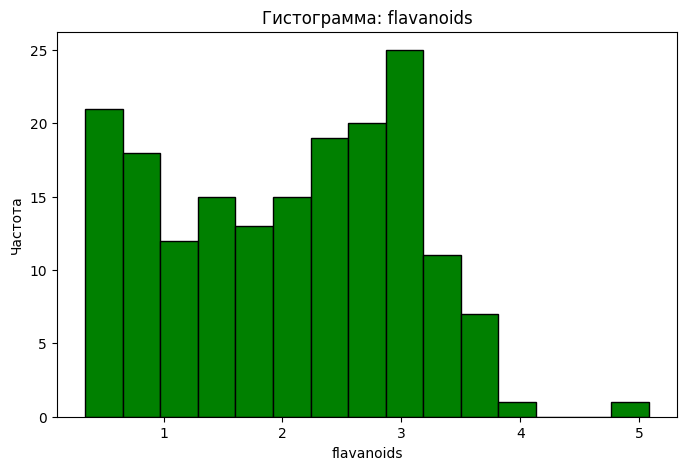

In [4]:
column_for_hist = 'flavanoids'
plt.figure(figsize=(8, 5))
plt.hist(df[column_for_hist], bins=15, color='green', edgecolor='black')
plt.xlabel(column_for_hist)
plt.ylabel('Частота')
plt.title(f'Гистограмма: {column_for_hist}')
plt.show()

In [5]:
# Создание категориального признака на основе alcohol
df['alcohol_category'] = pd.cut(df['alcohol'], 
                                 bins=3, 
                                 labels=['low', 'medium', 'high'])

print("Уникальные значения нового категориального признака:")
print(df['alcohol_category'].unique())
print("\nРаспределение по категориям:")
print(df['alcohol_category'].value_counts())

df.head()

Уникальные значения нового категориального признака:
['high', 'medium', 'low']
Categories (3, object): ['low' < 'medium' < 'high']

Распределение по категориям:
alcohol_category
medium    86
high      51
low       41
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_category
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,high
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,medium
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,medium
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,high
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,medium


OneHotEncoding

In [6]:
df_ohe = df.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_array = ohe.fit_transform(df_ohe[['alcohol_category']])

ohe_array_df = pd.DataFrame(
    ohe_array,
    columns=ohe.get_feature_names_out(['alcohol_category']),
    index=df_ohe.index
)

df_ohe_final = pd.concat([df_ohe, ohe_array_df], axis=1)
df_ohe_final.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,alcohol_category,alcohol_category_high,alcohol_category_low,alcohol_category_medium
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,high,1.0,0.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,medium,0.0,0.0,1.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,medium,0.0,0.0,1.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,high,1.0,0.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,medium,0.0,0.0,1.0


Label Encoding

In [7]:
label_mapper = {
    'low': 0,
    'medium': 1,
    'high': 2
}

df['alcohol_category_label'] = df['alcohol_category'].map(label_mapper)

print("Результат Label Encoding:")
df[['alcohol', 'alcohol_category', 'alcohol_category_label']].head()

Результат Label Encoding:


,alcohol,alcohol_category,alcohol_category_label
0,14.23,high,2
1,13.20,medium,1
2,13.16,medium,1
3,14.37,high,2
4,13.24,medium,1


In [8]:
scaler = StandardScaler()
df['flavanoids_scaled'] = scaler.fit_transform(df[['flavanoids']])

print("Результат стандартизации:")
df[['flavanoids', 'flavanoids_scaled']].head()

Результат стандартизации:


,flavanoids,flavanoids_scaled
0,3.06,1.034819
1,2.76,0.733629
2,3.24,1.215533
3,3.49,1.466525
4,2.69,0.663351


In [9]:
print("Статистика исходного признака flavanoids:")
print(df['flavanoids'].describe())
print("\nСтатистика scaled признака:")
print(df['flavanoids_scaled'].describe())

Статистика исходного признака flavanoids:
count    178.000000
mean       2.029270
std        0.998859
min        0.340000
25%        1.205000
50%        2.135000
75%        2.875000
max        5.080000
Name: flavanoids, dtype: float64

Статистика scaled признака:
count    1.780000e+02
mean    -3.991813e-16
std      1.002821e+00
min     -1.695971e+00
25%     -8.275393e-01
50%      1.061497e-01
75%      8.490851e-01
max      3.062832e+00
Name: flavanoids_scaled, dtype: float64


In [10]:
columns_to_show = ['alcohol', 'alcohol_category', 'alcohol_category_label', 
                   'flavanoids', 'flavanoids_scaled', 'target']

print("Итоговая таблица (первые 10 строк):")
df[columns_to_show].head(10)

Итоговая таблица (первые 10 строк):


,alcohol,alcohol_category,alcohol_category_label,flavanoids,flavanoids_scaled,target
0,14.23,high,2,3.06,1.034819,0
1,13.20,medium,1,2.76,0.733629,0
2,13.16,medium,1,3.24,1.215533,0
3,14.37,high,2,3.49,1.466525,0
4,13.24,medium,1,2.69,0.663351,0
5,14.20,high,2,3.39,1.366128,0
6,14.39,high,2,2.52,0.492677,0
7,14.06,high,2,2.51,0.482637,0
8,14.83,high,2,2.98,0.954502,0
9,13.86,high,2,3.15,1.125176,0
